# **Technical Note: Data Preprocessing**

## **Session 2: Data Cleaning and Quality Assessment**
This session introduces essential steps for cleaning and preparing data, using a marketing dataset collected through a retail customer survey. The dataset contains intentionally embedded quality issues, offering a hands-on opportunity to identify and correct them.

You’ll learn how to:

Detect and handle different types of missing and inconsistent data
Clean and standardize values
Identify outliers
Decide when to impute or drop variables
Apply common imputation strategies for various variable types
These tasks form the foundation of any reliable data mining process and are key to ensuring the integrity of downstream analysis and modeling.

## **🧭 Business Case: Improving Customer Insights for a Retail Chain**
A national retail chain in Peru wants to improve its marketing campaigns and customer retention strategies. To support this goal, the company launched an online survey to collect data from over 1,000 customers across regions.

The dataset reflects real-world imperfections: it includes **inconsistencies in text entries, missing values, outliers, and even irrelevant columns**. Our task is to act as data analysts hired to clean and prepare this dataset for further analysis, segmentation, and predictive modeling.

**Data Dictionary: Retail Customer Survey Dataset**

|       Variable        |                       Description                          |     Type      |
|-----------------------|------------------------------------------------------------|---------------|
| `customer_id`         | Unique ID per respondent                              	 |  Identifier   |
| `region`              | Peruvian region of the customer                            |	Categorical  |
| `age`                 | Age of respondent                                          |	Numeric      |
| `num_site_visits`     | Number of times the user visited the store website         |	Numeric      |
| `num_products_viewed` | Number of products viewed during last session              |	Numeric      |
| `purchase_made`       | Whether a purchase was made (Yes,No)                       |	Binary       |
| `satisfaction_rating` | Self-reported satisfaction level                           |	Ordinal      |
| `customer_segment`    | Segment classification (Loyal, New, Returning, Occasional) |	Categorical  |
| `preferred_channel`   | Communication preference (Email, SMS, Phone, In-store)     |	Categorical  |
| `income`              | Estimated monthly income in PEN	                         |  Numeric      |
| `avg_spend_per_visit` | Average spending per store visit                           |	Numeric      |
| `discount_used`       | Whether a discount code was used                           |	Binary       |
| `time_on_site_min`    | Time spent on website in minutes                           |	Numeric      |
| `page_load_time_sec`  | Average time it takes to load a page                       |	Numeric      |
| `browser`             | Web browser used to access the site                        |	Categorical  |
| `email_open_rate`     | Open rate of email campaigns (0-1)                         |	Numeric      |
| `clicked_ad`          | Whether the user clicked an advertisement                  |	Binary (0,1) |
| `returned_product`    | Whether a product was returned                             |	Binary       |
| `membership_years`    | Number of years with store membership                      |	Numeric      |
| `zipcode`             | Postal code of residence                                   |	Categorical  |
| `tracking_cookie`     | Irrelevant constant column (same value for all)            |	Character    |


### **Recommended Cleaning Workflow**

1. 🔁 **Remove duplicates**
    - Eliminate exact duplicates to avoid double-counting during imputation or analysis.

2. 🧹 **Handle inconsistencies and invalid entries**
    - Clean inconsistent string values (e.g., `"Lima"`, `"lima "`, `"LIMA"`).
    - Remove or correct invalid entries (e.g., `age = -5`).
    - Reason: You don’t want to impute or model on **dirty or unrealistic data**, as it may introduce bias or garbage.

3. 📊 **Detect and adjust outliers**
    - Use boxplots or histograms to find extreme values.
    - Decide whether to cap, remove, or flag them.
    - Reason: Outliers can skew means and standard deviations, which are often used in imputation.

4. 🔄 **Handle missing values**

    - Once the dataset is clean, consistent, and outlier-adjusted, you can address missing values.

    - Depending on the context, you may:

    - **Drop** rows with missing data (if few and missingness is random),

    - **Ignore** the variable (if it’s irrelevant or too sparse), or

    - **Impute** using a suitable method (e.g., mean, median, k-NN, multiple imputation) based on variable type and missingness pattern.

- Your choice should consider the **amount of missingness**, the **mechanism** (MCAR, MAR, MNAR), and the **impact on analysis**.

### **1. Load the Dataset**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Retail_Customer_Survey_with_Issues.csv")
df.head()

,customer_id,region,age,num_site_visits,num_products_viewed,purchase_made,satisfaction_rating,customer_segment,preferred_channel,income,...,discount_used,time_on_site_min,page_load_time_sec,browser,email_open_rate,clicked_ad,returned_product,membership_years,zipcode,tracking_cookie
0,1,Ancash,14.0,5,11,Yes,Unsatisfied,Occasional,Email,1815.52,...,Yes,13.3,2.35,Firfox,0.68,1,Yes,4,11001,XYZ123
1,2,Piura,24.0,6,15,No,Satisfied,New,Phone,3036.29,...,Yes,4.6,2.34,Firefox,0.13,0,No,0,4001,XYZ123
2,3,piura,16.0,5,12,No,Very Unsatisfied,Occasional,In-store,3020.66,...,Yes,13.7,2.87,Firefox,0.86,1,No,5,2001,XYZ123
3,4,lima,31.0,4,7,No,Satisfied,Returning,Email,3569.71,...,Yes,5.1,4.49,Edge,0.25,1,No,5,13001,XYZ123
4,5,La Libertad,35.0,4,7,No,Unsatisfied,Loyal,Email,2352.62,...,Yes,8.1,0.90,Safari,0.36,1,No,3,13001,XYZ123


### **2. Explore the data structure**
📌 **Goal:** Understand the dataset structure and identify key data quality issues.

In [2]:
# Inspect the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          1010 non-null   int64  
 1   region               1010 non-null   object 
 2   age                  960 non-null    float64
 3   num_site_visits      1010 non-null   int64  
 4   num_products_viewed  1010 non-null   int64  
 5   purchase_made        1010 non-null   object 
 6   satisfaction_rating  960 non-null    object 
 7   customer_segment     1010 non-null   object 
 8   preferred_channel    1010 non-null   object 
 9   income               960 non-null    float64
 10  avg_spend_per_visit  958 non-null    float64
 11  discount_used        1010 non-null   object 
 12  time_on_site_min     1010 non-null   float64
 13  page_load_time_sec   1010 non-null   float64
 14  browser              1010 non-null   object 
 15  email_open_rate      1010 non-null   f

In [3]:
df.describe(include="all")

,customer_id,region,age,num_site_visits,num_products_viewed,purchase_made,satisfaction_rating,customer_segment,preferred_channel,income,...,discount_used,time_on_site_min,page_load_time_sec,browser,email_open_rate,clicked_ad,returned_product,membership_years,zipcode,tracking_cookie
count,1010.000000,1010,960.000000,1010.000000,1010.000000,1010,960,1010,1010,960.000000,...,1010,1010.000000,1010.000000,1010,1010.000000,1010.000000,1010,1010.000000,1010.000000,1010
unique,NaN,11,NaN,NaN,NaN,2,5,4,4,NaN,...,2,NaN,NaN,7,NaN,NaN,2,NaN,NaN,1
top,NaN,Lima,NaN,NaN,NaN,No,Very Unsatisfied,Returning,SMS,NaN,...,No,NaN,NaN,Safari,NaN,NaN,Yes,NaN,NaN,XYZ123
freq,NaN,111,NaN,NaN,NaN,724,211,267,285,NaN,...,523,NaN,NaN,215,NaN,NaN,516,NaN,NaN,1010
mean,500.111881,NaN,35.077083,5.419802,9.874257,NaN,NaN,NaN,NaN,3021.533146,...,NaN,8.037822,3.016030,NaN,0.501416,0.503960,NaN,3.023762,8944.564356,NaN
std,288.376128,NaN,10.359356,6.994689,3.025336,NaN,NaN,NaN,NaN,7066.843061,...,NaN,3.871823,1.152293,NaN,0.290075,0.500232,NaN,1.720692,5076.596955,NaN
min,1.000000,NaN,-5.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,-192.240000,...,NaN,0.000000,0.020000,NaN,0.000000,0.000000,NaN,0.000000,2001.000000,NaN
25%,251.250000,NaN,28.000000,4.000000,8.000000,NaN,NaN,NaN,NaN,2000.307500,...,NaN,5.200000,2.220000,NaN,0.250000,0.000000,NaN,2.000000,4001.000000,NaN
50%,499.500000,NaN,35.000000,5.000000,10.000000,NaN,NaN,NaN,NaN,2504.090000,...,NaN,8.000000,3.000000,NaN,0.510000,1.000000,NaN,3.000000,11001.000000,NaN
75%,748.750000,NaN,42.000000,6.000000,12.000000,NaN,NaN,NaN,NaN,3057.900000,...,NaN,10.500000,3.827500,NaN,0.760000,1.000000,NaN,4.000000,13001.000000,NaN


In [4]:
from skimpy import skim

skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1010   │ │ string      │ 9     │                                                          │
│ │ Number of columns │ 21     │ │ int64       │ 6     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 6     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column         ┃ NA ┃ NA %            ┃ mean   ┃ sd     ┃ p0     ┃ p25   ┃ p50   ┃ p75   ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │ customer_id    │  0 │               0 │  500.1 │  288.4 │      1 │ 251.2 │ 499.5 │ 748.8 │   1000 │ ▇▇▇▇▇▇ │  │
│ │ age            │ 50 │ 4.9504950495049 │  35.08 │  10.36 │     -5 │    28 │    35 │    42 │     61 │  ▁▃▇▅▂ │  │
│ │                │    │             505 │        │        │        │       │       │       │        │        │  │
│ │ num_site_visit │  0 │               0 │   5.42 │  6.995 │      0 │     4 │     5 │     6 │    100 │   ▇    │  │
│ │ s              │    │                 │        │        │        │       │       │       │        │        │  │
│ │ num_products_v │  0 │               0 │  9.874 │  3.025 │      1 │     8 │    10 │    12 │     21 │  ▅▇▇▁  │  │
│ │ iewed          │    │                 │        │        │        │       │       │       │        │        │  │
│ │ income         │ 50 │ 4.9504950495049 │   3022 │   7067 │ -192.2 │  2000 │  2504 │  3058 │ 100000 │   ▇    │  │
│ │                │    │             505 │        │        │        │       │       │       │        │        │  │
│ │ avg_spend_per_ │ 52 │ 5.1485148514851 │  198.7 │  50.21 │  61.43 │ 162.8 │ 197.5 │ 233.3 │  351.4 │ ▁▅▇▇▃  │  │
│ │ visit          │    │              49 │        │        │        │       │       │       │        │        │  │
│ │ time_on_site_m │  0 │               0 │  8.038 │  3.872 │      0 │   5.2 │     8 │  10.5 │   21.3 │ ▃▆▇▅▁  │  │
│ │ in             │    │                 │        │        │        │       │       │       │        │        │  │
│ │ page_load_time │  0 │               0 │  3.016 │  1.152 │   0.02 │  2.22 │     3 │ 3.828 │   6.73 │ ▁▅▇▆▂  │  │
│ │ _sec           │    │                 │        │        │        │       │       │       │        │        │  │
│ │ email_open_rat │  0 │               0 │ 0.5014 │ 0.2901 │      0 │  0.25 │  0.51 │  0.76 │      1 │ ▇▇▆▇▇▇ │  │
│ │ e              │    │                 │        │        │        │       │       │       │        │        │  │
│ │ clicked_ad     │  0 │               0 │  0.504 │ 0.5002 │      0 │     0 │     1 │     1 │      1 │ ▇    ▇ │  │
│ │ membership_yea │  0 │               0 │  3.024 │  1.721 │      0 │     2 │     3 │     4 │     11 │  ▃▇▅▁  │  │
│ │ rs             │    │                 │        │        │        │       │       │       │        │        │  │
│ │ zipcode        │  0 │               0 │   8945 │   5077 │   2001 │  4001 │ 11000 │ 13000 │  15000 │ ▇   ▅▇ │  │
│ └────────────────┴────┴─────────────────┴────────┴────

In [5]:
print(f"Numero de datos duplicados: {df.duplicated().sum()}")

Numero de datos duplicados: 9


In [6]:
df[df.duplicated()].sort_values('customer_id')

,customer_id,region,age,num_site_visits,num_products_viewed,purchase_made,satisfaction_rating,customer_segment,preferred_channel,income,...,discount_used,time_on_site_min,page_load_time_sec,browser,email_open_rate,clicked_ad,returned_product,membership_years,zipcode,tracking_cookie
1005,15,lima,38.0,5,9,No,Unsatisfied,Loyal,Email,3087.33,...,Yes,1.2,3.23,Safari,0.53,1,No,6,11001,XYZ123
1003,176,Junin,22.0,6,7,No,Unsatisfied,Returning,SMS,2621.76,...,Yes,8.8,3.03,Edge,0.68,0,Yes,1,11001,XYZ123
1001,321,Arequipa,40.0,4,9,Yes,Very Unsatisfied,Returning,SMS,2413.47,...,No,5.0,3.42,Chrome,0.91,1,Yes,2,2001,XYZ123
1004,357,Lima,36.0,4,13,Yes,Neutral,Occasional,Phone,4058.53,...,No,12.7,3.80,Edge,0.76,1,No,1,15001,XYZ123
1000,492,Cusco,46.0,6,6,No,Neutral,Occasional,SMS,2169.39,...,No,7.3,4.63,IE,0.48,1,No,2,15001,XYZ123
1009,499,CUSCO,31.0,5,9,No,Neutral,Occasional,SMS,1697.05,...,No,5.7,3.99,Firefox,0.38,1,No,2,13001,XYZ123
1006,555,LIMA,46.0,5,10,No,Very Unsatisfied,Occasional,SMS,2891.50,...,No,2.9,2.42,Safari,0.13,1,No,3,15001,XYZ123
1008,667,LIMA,34.0,6,10,No,Very Satisfied,New,Phone,2915.10,...,No,7.3,4.11,IE,0.79,0,No,7,11001,XYZ123
1007,691,La Libertad,51.0,5,9,No,Satisfied,Loyal,In-store,2066.34,...,No,13.9,0.72,Edge,0.08,0,Yes,2,13001,XYZ123


In [7]:
print(f"Numero de filas (antes): {len(df)}")

df = df.drop_duplicates()
print(f"Número de filas (despues): {len(df)}")

Numero de filas (antes): 1010
Número de filas (despues): 1001


In [8]:
result = {col: df[col].unique() for col in df.select_dtypes(include=['object']).columns}
for col, valores in result.items():
    print(f"\n{col}:")
    print(valores)


region:
['Ancash' 'Piura' 'piura ' 'lima' 'La Libertad' 'CUSCO' 'Arequipa' 'Junin'
 'Cusco' 'Lima' 'LIMA ']

purchase_made:
['Yes' 'No']

satisfaction_rating:
['Unsatisfied' 'Satisfied' 'Very Unsatisfied' 'Neutral' 'Very Satisfied'
 nan]

customer_segment:
['Occasional' 'New' 'Returning' 'Loyal']

preferred_channel:
['Email' 'Phone' 'In-store' 'SMS']

discount_used:
['Yes' 'No']

browser:
['Firfox' 'Firefox' 'Edge' 'Safari' 'Chrome' 'IE' 'Chorme']

returned_product:
['Yes' 'No']

tracking_cookie:
['XYZ123']


In [9]:
df.drop('tracking_cookie', axis=1, inplace=True)

ESTRUCTURACIÓN DE LAS VARIABLES CATEGORIALES Y BINARIAS

In [10]:
# Step1: Clean binary variables

# Define a list with the names of binary or categorical variables
binary_vars = ["purchase_made", "discount_used", "returned_product", "satisfaction_rating"]

# Change "" to NA and standarize to lowercase
df[binary_vars] = (df[binary_vars].apply(lambda s: s.str.strip().str.lower()).replace("",pd.NA))
df[binary_vars].apply(pd.unique)

purchase_made                                                  [yes, no]
discount_used                                                  [yes, no]
returned_product                                               [yes, no]
satisfaction_rating    [unsatisfied, satisfied, very unsatisfied, neu...
dtype: object

In [11]:
# Step2: Convert all letters in the region column to lowercase, standarize the cleaned region names and capitalize first letter
# Before:
print("Valores iniciales para region: ", df['region'].unique())
print(df.groupby('region').size())

print("Valores iniciales para browser: ", df["browser"].unique())
print(df.groupby('browser').size())

Valores iniciales para region:  ['Ancash' 'Piura' 'piura ' 'lima' 'La Libertad' 'CUSCO' 'Arequipa' 'Junin'
 'Cusco' 'Lima' 'LIMA ']
region
Ancash          86
Arequipa       103
CUSCO          100
Cusco           79
Junin           87
LIMA            88
La Libertad    102
Lima           110
Piura           84
lima            91
piura           71
dtype: int64
Valores iniciales para browser:  ['Firfox' 'Firefox' 'Edge' 'Safari' 'Chrome' 'IE' 'Chorme']
browser
Chorme      12
Chrome     176
Edge       188
Firefox    194
Firfox       8
IE         210
Safari     213
dtype: int64


In [12]:
# All letters to lowercase:
variables = ['region','browser']
df[variables] = (df[variables].apply(lambda x: x.str.strip().str.lower()))

# Capitalize the first letter of the column 'region'
df['region'] = df['region'].str.capitalize()
df['region'] = df['region'].replace({
        'La libertad': 'La Libertad'
})
print(df.groupby('region').size())

region
Ancash          86
Arequipa       103
Cusco          179
Junin           87
La Libertad    102
Lima           289
Piura          155
dtype: int64


In [13]:
# Standarize the variable 'browser':
df['browser'] = df['browser'].str.capitalize()
df['browser'] = df['browser'].replace({
    'Firfox': 'Firefox',
    'Chorme': 'Chrome',
    'Ie': 'IE'
})
print(df.groupby('browser').size())

browser
Chrome     188
Edge       188
Firefox    202
IE         210
Safari     213
dtype: int64


CONVERTIR VARIABLES SELECTAS COMO FACTORES

In [14]:
var_selected = ["region", "browser", "purchase_made", "discount_used",
                "returned_product", "satisfaction_rating", "customer_segment", 
                "preferred_channel"]

df[var_selected] = df[var_selected].astype('category')
df[var_selected].dtypes

region                 category
browser                category
purchase_made          category
discount_used          category
returned_product       category
satisfaction_rating    category
customer_segment       category
preferred_channel      category
dtype: object

HANDLE OUTLIERS AND INVALID ENTRIES

In [15]:
#Visualize numeric variables
df.describe()

,customer_id,age,num_site_visits,num_products_viewed,income,avg_spend_per_visit,time_on_site_min,page_load_time_sec,email_open_rate,clicked_ad,membership_years,zipcode
count,1001.000000,951.000000,1001.000000,1001.000000,951.000000,951.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,500.839161,35.047319,5.422577,9.881119,3024.975131,198.633270,8.045355,3.013826,0.501189,0.502498,3.024975,8919.081918
std,288.874359,10.372071,7.025685,3.032961,7099.864950,50.331034,3.870434,1.152616,0.290208,0.500244,1.717666,5079.299432
min,1.000000,-5.000000,0.000000,1.000000,-192.240000,61.430000,0.000000,0.020000,0.000000,0.000000,0.000000,2001.000000
25%,251.000000,28.000000,3.000000,8.000000,1998.015000,162.425000,5.200000,2.220000,0.250000,0.000000,2.000000,4001.000000
50%,501.000000,35.000000,5.000000,10.000000,2504.000000,197.620000,8.100000,2.990000,0.510000,1.000000,3.000000,11001.000000
75%,751.000000,42.000000,6.000000,12.000000,3058.240000,233.235000,10.500000,3.820000,0.760000,1.000000,4.000000,13001.000000
max,1000.000000,61.000000,100.000000,21.000000,99999.000000,351.450000,21.300000,6.730000,1.000000,1.000000,11.000000,15001.000000


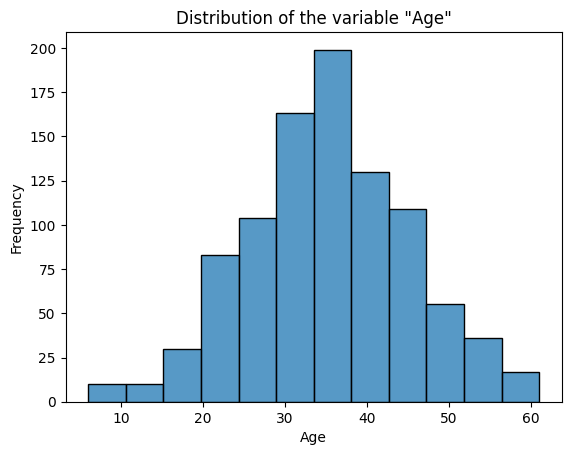

In [16]:
# 1. "Age": Minimun value is -5 and 50 missing, so set invalides to NA
# Remove invalid age entries
df['age'] = df['age'].where(df['age'].between(0,100),pd.NA)

# Histogram for 'Age'
sns.histplot(df['age'].dropna(), bins=12)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of the variable "Age"')
plt.show()

In [17]:
# 2. "Income":
df['income'].describe()

count      951.000000
mean      3024.975131
std       7099.864950
min       -192.240000
25%       1998.015000
50%       2504.000000
75%       3058.240000
max      99999.000000
Name: income, dtype: float64

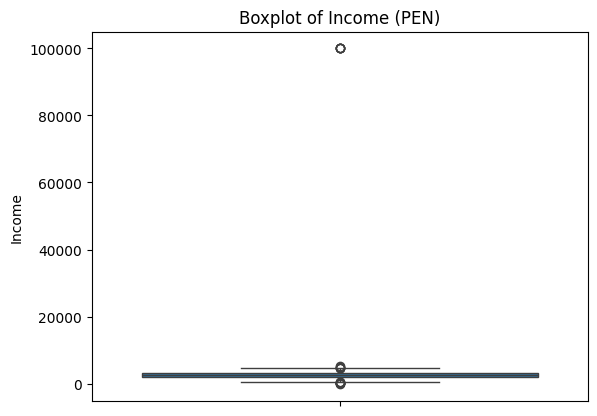

In [18]:
# If you loo at the maximum value, it's too far from the average. It will be clearer when you create a graph
sns.boxplot(df['income'].dropna())
plt.ylabel('Income')
plt.title('Boxplot of Income (PEN)')
plt.show()

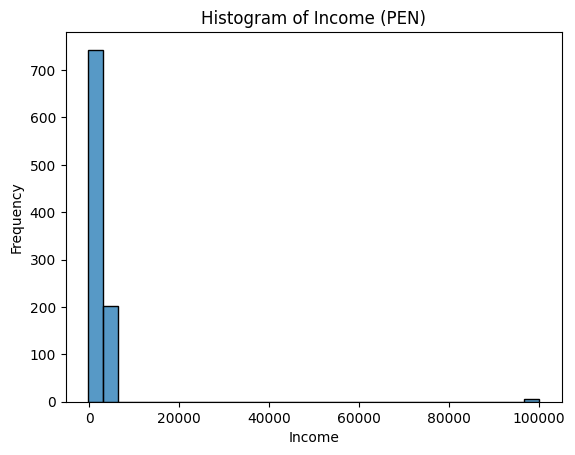

In [19]:
sns.histplot(df['income'].dropna(), bins=30)
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.title('Histogram of Income (PEN)')
plt.show()

In [20]:
# Check how many are greater than a realistic threshold (e.g., 10000 PEN)
(df['income'] > 10000).sum()

np.int64(5)

In [21]:
df[df['income']>10000]

,customer_id,region,age,num_site_visits,num_products_viewed,purchase_made,satisfaction_rating,customer_segment,preferred_channel,income,avg_spend_per_visit,discount_used,time_on_site_min,page_load_time_sec,browser,email_open_rate,clicked_ad,returned_product,membership_years,zipcode
373,374,Lima,29.0,4,14,no,very satisfied,Loyal,SMS,99999.0,241.70,yes,8.3,1.81,Edge,0.14,0,no,4,4001
664,665,Junin,NaN,5,6,yes,satisfied,New,Phone,99999.0,251.66,yes,4.0,5.15,IE,0.79,1,yes,2,2001
809,810,Junin,32.0,4,14,no,very unsatisfied,Loyal,Phone,99999.0,296.70,no,8.1,3.29,Edge,0.80,0,yes,1,15001
852,853,Arequipa,50.0,4,11,no,very satisfied,Loyal,In-store,99999.0,153.12,yes,6.8,1.46,Edge,0.59,1,no,1,15001
916,917,Piura,52.0,5,9,yes,very satisfied,Occasional,Email,99999.0,194.08,yes,9.6,4.81,Firefox,0.56,0,yes,2,11001


In [22]:
df['income'] = np.where(df['income'] <= 0, np.nan, df['income'])

In [23]:
q1_income = df['income'].quantile(0.25)
q3_income = df['income'].quantile(0.75)
iqr_income = q3_income - q1_income

upper_bound_income = q3_income + 1.5*iqr_income

df['income_capped'] = np.where(df['income'] > upper_bound_income, upper_bound_income, df['income'])

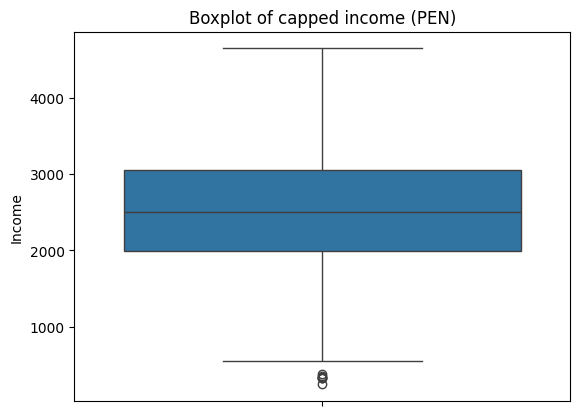

In [24]:
# Visualize after capping
sns.boxplot(df['income_capped'].dropna())
plt.ylabel('Income')
plt.title('Boxplot of capped income (PEN)')
plt.show()

In [25]:
# Summary statistics
df['num_site_visits'].describe()

count    1001.000000
mean        5.422577
std         7.025685
min         0.000000
25%         3.000000
50%         5.000000
75%         6.000000
max       100.000000
Name: num_site_visits, dtype: float64

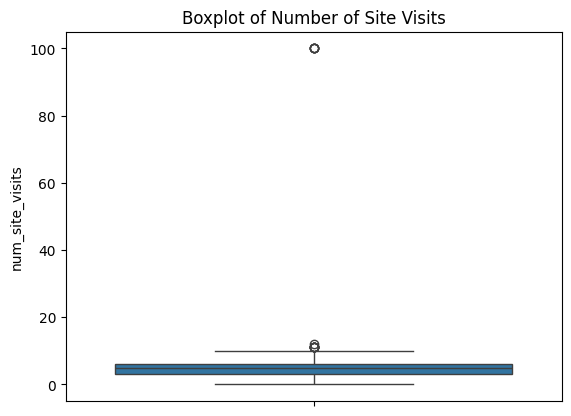

In [26]:
# Boxplot
sns.boxplot(df['num_site_visits'].dropna())
plt.title('Boxplot of Number of Site Visits')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

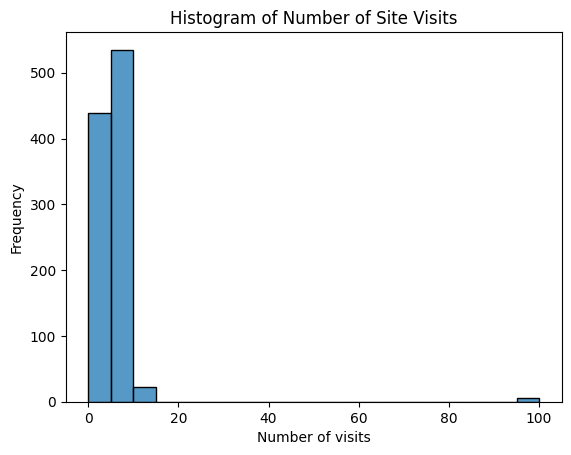

In [27]:
sns.histplot(df['num_site_visits'].dropna(), bins=20)
plt.xlabel('Number of visits')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Site Visits')
plt.show

In [28]:
#Check how many are greater than a realistic threshold (e.g. 50 visits per session)
(df['num_site_visits']>50).sum()

np.int64(5)

In [29]:
df.loc[df['num_site_visits']>50]

,customer_id,region,age,num_site_visits,num_products_viewed,purchase_made,satisfaction_rating,customer_segment,preferred_channel,income,...,discount_used,time_on_site_min,page_load_time_sec,browser,email_open_rate,clicked_ad,returned_product,membership_years,zipcode,income_capped
165,166,Junin,25.0,100,9,no,very unsatisfied,Loyal,SMS,2075.02,...,no,8.1,4.03,IE,0.15,1,yes,2,2001,2075.02
306,307,Junin,21.0,100,10,no,very satisfied,New,Phone,3879.49,...,no,7.3,2.31,Edge,0.41,1,no,3,4001,3879.49
311,312,Piura,37.0,100,10,no,very unsatisfied,Occasional,Email,1040.90,...,no,8.2,2.79,Firefox,0.56,1,yes,2,13001,1040.90
538,539,Lima,46.0,100,14,no,NaN,Occasional,In-store,2260.84,...,no,5.6,4.02,Chrome,0.60,0,no,4,2001,2260.84
613,614,Lima,23.0,100,5,no,satisfied,New,In-store,3316.39,...,no,10.2,2.75,IE,0.85,0,yes,2,15001,3316.39


In [30]:
# Treat unrealistic values as NA
df['num_site_visits'] = df['num_site_visits'].where(df['num_site_visits'] <= 50, pd.NA)

In [31]:
# Calculate IQR bounds
q1 = df['num_site_visits'].quantile(0.25)
q3 = df['num_site_visits'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5*q1

df['num_site_visits_capped'] = np.where(df['num_site_visits'] > upper_bound, upper_bound, df['num_site_visits'])

MISSING DATA

In [32]:
df.isna().sum()

customer_id                0
region                     0
age                       55
num_site_visits            5
num_products_viewed        0
purchase_made              0
satisfaction_rating       50
customer_segment           0
preferred_channel          0
income                    51
avg_spend_per_visit       50
discount_used              0
time_on_site_min           0
page_load_time_sec         0
browser                    0
email_open_rate            0
clicked_ad                 0
returned_product           0
membership_years           0
zipcode                    0
income_capped             51
num_site_visits_capped     5
dtype: int64

In [33]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 1001   │ │ float64     │ 9     │ │ region                │                                │
│ │ Number of columns │ 22     │ │ category    │ 8     │ │ purchase_made         │                                │
│ └───────────────────┴────────┘ │ int64       │ 5     │ │ satisfaction_rating   │                                │
│                                └─────────────┴───────┘ │ customer_segment      │                                │
│                                                        │ preferred_channel     │                                │
│                                                        │ discount_used         │                                │
│                                                        │ browser               │                                │
│                                                        │ returned_product      │                                │
│                                                        └───────────────────────┘                                │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column          ┃ NA ┃ NA %            ┃ mean   ┃ sd     ┃ p0    ┃ p25   ┃ p50   ┃ p75   ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │ customer_id     │  0 │               0 │  500.8 │  288.9 │     1 │   251 │   501 │   751 │   1000 │ ▇▇▇▇▇▇ │  │
│ │ age             │ 55 │ 5.4945054945054 │  35.26 │  9.981 │     6 │ 28.25 │    35 │    42 │     61 │  ▃▆▇▃▁ │  │
│ │                 │    │             945 │        │        │       │       │       │       │        │        │  │
│ │ num_site_visits │  5 │ 0.4995004995004 │  4.948 │  2.106 │     0 │     3 │     5 │     6 │     12 │ ▁▅▇▅▂  │  │
│ │                 │    │             995 │        │        │       │       │       │       │        │        │  │
│ │ num_products_vi │  0 │               0 │  9.881 │  3.033 │     1 │     8 │    10 │    12 │     21 │  ▅▇▇▁  │  │
│ │ ewed            │    │                 │        │        │       │       │       │       │        │        │  │
│ │ income          │ 51 │ 5.0949050949050 │   3028 │   7103 │ 246.7 │  1999 │  2504 │  3059 │ 100000 │   ▇    │  │
│ │                 │    │              95 │        │        │       │       │       │       │        │        │  │
│ │ avg_spend_per_v │ 50 │ 4.9950049950049 │  198.6 │  50.33 │ 61.43 │ 162.4 │ 197.6 │ 233.2 │  351.4 │ ▁▅▇▇▃  │  │
│ │ isit            │    │              95 │        │        │       │       │       │       │        │        │  │
│ │ time_on_site_mi │  0 │               0 │  8.045 │   3.87 │     0 │   5.2 │   8.1 │  10.5 │   21.3 │ ▃▆▇▅▁  │  │
│ │ n               │    │                 │        │        │       │       │       │       │        │        │  │
│ │ page_load_time_ │  0 │               0 │  3.014 │  1.153 │  0.02 │  2.22 │  2.99 │  3.82 │   6.73 │ ▁▅▇▆▂  │  │
│ │ sec             │    │                 │        │        │       │       │       │       │        │        │  │
│ │ email_open_rate │  0 │               0 │ 0.5012 │ 0.2902 │     0 │  0.25 │  0.51 │  0.76 │      1 │ ▇▇▆▇▇▇ │  │
│ │ clicked_ad      │  0 │               0 │ 0.5025 │ 0.

In [34]:
df.isna().sum(axis=1).value_counts().sort_index()

0    813
1    118
2     61
3      9
Name: count, dtype: int64

In [35]:
#pd.DataFrame({
#    "variable": df.columns,
#    "n_miss": df.isna().sum(),
#    "pct_miss": df.isna().mean()
#}).reset_index(drop=True).sort_values("pct_miss",ascending=False)

pd.DataFrame({
    'variable': df.columns,
    'n_miss': df.isnull().sum().values,
    'pct_miss': (df.isnull().mean().values*100).round(2)
}).sort_values(by='pct_miss', ascending=False)

,variable,n_miss,pct_miss
2,age,55,5.49
9,income,51,5.09
20,income_capped,51,5.09
10,avg_spend_per_visit,50,5.00
6,satisfaction_rating,50,5.00
3,num_site_visits,5,0.50
21,num_site_visits_capped,5,0.50
4,num_products_viewed,0,0.00
0,customer_id,0,0.00
1,region,0,0.00


In [36]:
# Visualize missingness by group

miss_pct = df.groupby('customer_segment').apply(lambda x: x.isna().mean()*100).T.sort_index(ascending=False)
miss_pct

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9264\119935134.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  miss_pct = df.groupby('customer_segment').apply(lambda x: x.isna().mean()*100).T.sort_index(ascending=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9264\119935134.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  miss_pct = df.groupby('customer_segment').apply(lambda x: x.isna().mean()*100).T.sort_index(ascending=False)


customer_segment,Loyal,New,Occasional,Returning
zipcode,0.000000,0.000000,0.000000,0.000000
time_on_site_min,0.000000,0.000000,0.000000,0.000000
satisfaction_rating,6.048387,3.629032,6.666667,3.773585
returned_product,0.000000,0.000000,0.000000,0.000000
region,0.000000,0.000000,0.000000,0.000000
purchase_made,0.000000,0.000000,0.000000,0.000000
preferred_channel,0.000000,0.000000,0.000000,0.000000
page_load_time_sec,0.000000,0.000000,0.000000,0.000000
num_site_visits_capped,0.403226,0.806452,0.833333,0.000000
num_site_visits,0.403226,0.806452,0.833333,0.000000


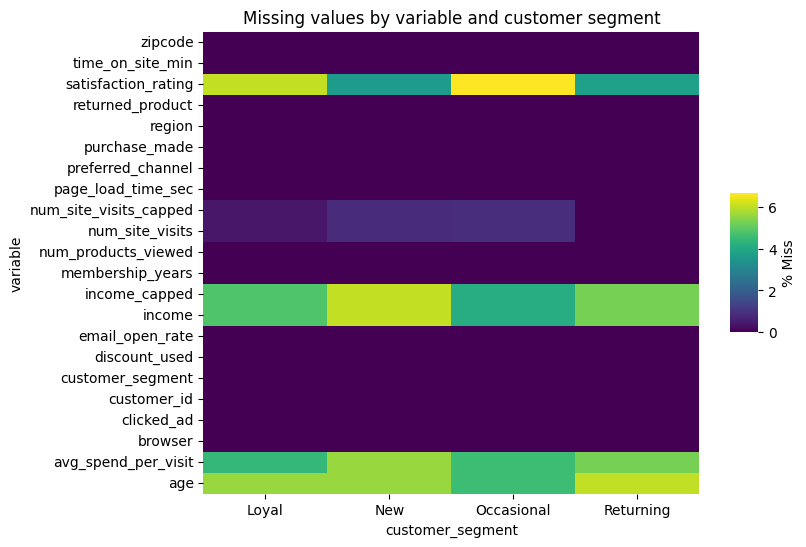

In [37]:
plt.figure(figsize=(8,6))
sns.heatmap(
    miss_pct,
    cmap='viridis',
    cbar_kws={
        "label": "% Miss",
        "shrink": 0.3,
        "aspect": 5}
)

plt.xlabel("customer_segment")
plt.ylabel("variable")
plt.title("Missing values by variable and customer segment")
plt.show()

In [38]:
# Create binary indicators
df = (df.assign(
    miss_age = lambda y: y['age'].isna(),
    miss_income = lambda y: y['income'].isna(),
    miss_satisfaction = lambda y: y['satisfaction_rating'].isna(),
    miss_avg_spend = lambda y: y['avg_spend_per_visit'].isna()
))

2A. Chi-square tests

In [39]:
#Check if missingness in age is related to customer segment
from scipy.stats import chi2_contingency

contingency1 = pd.crosstab(df['miss_age'], df['customer_segment'])
chi2, p_value, dof, expected = chi2_contingency(contingency1)
print(f"p_value: {p_value.round(4)}")

p_value: 0.9064


In [40]:
#Check if missigness in income is related to customer segment
contingency2 = pd.crosstab(df['miss_income'], df['customer_segment'])
chi2, p_value, dof, expected = chi2_contingency(contingency2)
print(f"p_value: {p_value.round(4)}")

p_value: 0.8141


In [41]:
#Same for satisfaction rating
contingency3 = pd.crosstab(df['miss_satisfaction'], df['customer_segment'])
chi2, p_value, dof, expected = chi2_contingency(contingency3)
print(f"p_value: {p_value.round(4)}")

p_value: 0.2837


In [42]:
#Same for miss_avg_spend
contingency4 = pd.crosstab(df['miss_avg_spend'], df['customer_segment'])
chi2, p_value, dof, expected = chi2_contingency(contingency4)
print(f"p_value: {p_value.round(4)}")

p_value: 0.9152


2B. T-tests: Missingness vs. numeric predictors

In [43]:
# Are older customers more likely to skip income?
import pingouin as pg

def t_test(var1, var2, data):
    # Calculate the mean in group FALSE and TRUE
    means = data.groupby(var2)[var1].mean()
    # Calculate the Welch Two Sample t-test
    res_t = pg.ttest(
        x=data.loc[data[var2] == False, var1],
        y=data.loc[data[var2] == True, var1]
    )
    print(res_t)
    print("\nSample estimates:")
    print(means.rename({
        False: "mean in group FALSE",
        True: "mean in group TRUE"
    }))

t_test('age', 'miss_income', data=df)

               T        dof alternative     p-val         CI95%   cohen-d  \
T-test  1.317992  52.195037   two-sided  0.193262  [-1.01, 4.9]  0.194525   

        BF10     power  
T-test  0.36  0.258954  

Sample estimates:
miss_income
mean in group FALSE    35.357461
mean in group TRUE     33.416667
Name: age, dtype: float64


In [44]:
# Do customers with missing avg spend differ in income
t_test('income_capped', 'miss_avg_spend',data=df)

               T        dof alternative     p-val              CI95%  \
T-test -0.236826  51.556513   two-sided  0.813731  [-259.07, 204.39]   

         cohen-d   BF10     power  
T-test  0.033544  0.166  0.055767  

Sample estimates:
miss_avg_spend
mean in group FALSE    2524.089228
mean in group TRUE     2551.432340
Name: income_capped, dtype: float64


Impute Missing Values

In [45]:
# Calculate missingness and assign category
missing_summary = (df.isnull().mean()*100).rename_axis('variable').reset_index(name='pct_missing').sort_values('pct_missing',ascending=False)
missing_summary['category'] = np.select([missing_summary['pct_missing'] == 0,
                                        missing_summary['pct_missing'] > 30,
                                        (missing_summary['pct_missing'] > 10) & (missing_summary['pct_missing'] <= 30),
                                        (missing_summary['pct_missing'] > 0) & (missing_summary['pct_missing'] <= 10)],
                                        ["None (No action needed)",
                                        "High (Consider dropping)",
                                        "Moderate (Impute with caution)",
                                        "Low (Safe for imputation)"],
                                        default='Uncategorized')

missing_summary

,variable,pct_missing,category
2,age,5.494505,Low (Safe for imputation)
9,income,5.094905,Low (Safe for imputation)
20,income_capped,5.094905,Low (Safe for imputation)
6,satisfaction_rating,4.995005,Low (Safe for imputation)
10,avg_spend_per_visit,4.995005,Low (Safe for imputation)
3,num_site_visits,0.499500,Low (Safe for imputation)
21,num_site_visits_capped,0.499500,Low (Safe for imputation)
5,purchase_made,0.000000,None (No action needed)
1,region,0.000000,None (No action needed)
0,customer_id,0.000000,None (No action needed)


In [46]:
# Drop high-missing variables
vars_to_drop = missing_summary['variable'][missing_summary['category'] == 'High (Consider dropping)']
df.drop(columns=vars_to_drop)

,customer_id,region,age,num_site_visits,num_products_viewed,purchase_made,satisfaction_rating,customer_segment,preferred_channel,income,...,clicked_ad,returned_product,membership_years,zipcode,income_capped,num_site_visits_capped,miss_age,miss_income,miss_satisfaction,miss_avg_spend
0,1,Ancash,14.0,5.0,11,yes,unsatisfied,Occasional,Email,1815.52,...,1,yes,4,11001,1815.52,5.0,False,False,False,False
1,2,Piura,24.0,6.0,15,no,satisfied,New,Phone,3036.29,...,0,no,0,4001,3036.29,6.0,False,False,False,False
2,3,Piura,16.0,5.0,12,no,very unsatisfied,Occasional,In-store,3020.66,...,1,no,5,2001,3020.66,5.0,False,False,False,False
3,4,Lima,31.0,4.0,7,no,satisfied,Returning,Email,3569.71,...,1,no,5,13001,3569.71,4.0,False,False,False,False
4,5,La Libertad,35.0,4.0,7,no,unsatisfied,Loyal,Email,2352.62,...,1,no,3,13001,2352.62,4.0,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,997,Lima,10.0,6.0,18,no,satisfied,Occasional,SMS,1589.58,...,0,no,1,13001,1589.58,6.0,False,False,False,False
997,998,Cusco,43.0,6.0,8,no,unsatisfied,Loyal,Email,2691.20,...,1,yes,6,11001,2691.20,6.0,False,False,False,False
998,999,Lima,42.0,3.0,15,no,very satisfied,New,Email,3294.47,...,1,yes,3,2001,3294.47,3.0,False,False,False,False
999,1000,Lima,32.0,3.0,17,yes,unsatisfied,Occasional,Phone,2001.05,...,0,no,4,13001,2001.05,3.0,False,False,False,False


In [47]:
# Median for numeric variables
df['age'] = np.where(df['age'].isna(), df['age'].median(), df['age'])
df['income_capped'] = np.where(df['income_capped'].isna(), df['income_capped'].median(), df['income_capped'])
df['avg_spend_per_visit'] = np.where(df['avg_spend_per_visit'].isna(), df['avg_spend_per_visit'].median(), df['avg_spend_per_visit'])
df['num_site_visits_capped'] = np.where(df['num_site_visits_capped'].isna(), df['num_site_visits_capped'].median(), df['num_site_visits_capped'])

In [48]:
# Mode Imputation:
df['satisfaction_rating'] = np.where(df['satisfaction_rating'].isna(), 
                                     df['satisfaction_rating'].dropna().mode()[0], df['satisfaction_rating'])